In [1]:
import pandas as pd

df = pd.read_csv("C:/Users/kalya/NTCC/NHANES/CVD_Data_Analysis_R/FINAL_CVD_MASTER_DATASET_CLEANED.csv")

print(df.shape)

(15560, 647)


In [2]:
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

df.head()

Rows    : 15560
Columns : 647


,SEQN,SDMVPSU,SDMVSTRA,WTINTPRP,WTMECPRP,RIAGENDR,RIDAGEYR,RIDRETH1,RIDRETH3,DMDEDUC2,...,URXUAS5_WASMISSING,URXUHG_WASMISSING,URXUBA_WASMISSING,URXUCD_WASMISSING,URXUCO_WASMISSING,URXUPB_WASMISSING,URXUSB_WASMISSING,URXUTL_WASMISSING,URXUTU_WASMISSING,URXUAS_WASMISSING
0,109263,3,156,7891.762435,8951.815567,1,2,5,6,4,...,1,1,1,1,1,1,1,1,1,1
1,109264,1,155,11689.747264,12271.157043,2,13,1,1,4,...,1,1,1,1,1,1,1,1,1,1
2,109265,1,157,16273.825939,16658.764203,1,2,3,3,4,...,1,1,1,1,1,1,1,1,1,1
3,109266,2,168,7825.646112,8154.968193,2,29,5,6,5,...,0,0,0,0,0,0,0,0,0,0
4,109267,1,156,26379.991724,0.000000,2,21,2,2,4,...,1,1,1,1,1,1,1,1,1,1


In [3]:
# classify columns based on NHANES prefixes

variable_groups = {

    "Demographics": [
        "RIA",
        "RID",
        "DMD",
        "IND"
    ],

    "Body_Measurements": [
        "BMX"
    ],

    "Blood_Pressure": [
        "BPX",
        "BPQ"
    ],

    "Medical_History": [
        "MCQ"
    ],

    "Diabetes": [
        "DIQ"
    ],

    "Smoking": [
        "SMQ"
    ],

    "Alcohol": [
        "ALQ"
    ],

    "Physical_Activity": [
        "PAQ",
        "PAD"
    ],

    "Sleep": [
        "SLQ"
    ],

    "Diet": [
        "DR1",
        "DR2",
        "DS"
    ],

    "Laboratory": [
        "LBX",
        "LBD"
    ],

    "Urine_Biomarkers": [
        "URX"
    ],

    "Occupation": [
        "OCQ"
    ],

    "Health_Insurance": [
        "HIQ"
    ],

    "Depression": [
        "DPQ"
    ]
}

In [4]:
# Assigning every variable to a Domain

def assign_group(column):

    for group, prefixes in variable_groups.items():

        for prefix in prefixes:

            if column.startswith(prefix):

                return group

    return "Other"


dictionary = pd.DataFrame({

    "Variable": df.columns

})

dictionary["Group"] = dictionary["Variable"].apply(assign_group)

dictionary.head()


,Variable,Group
0,SEQN,Other
1,SDMVPSU,Other
2,SDMVSTRA,Other
3,WTINTPRP,Other
4,WTMECPRP,Other


In [5]:
# counting Variable

dictionary["Group"].value_counts()

Group
Diet                 336
Smoking               84
Laboratory            44
Physical_Activity     34
Urine_Biomarkers      32
Blood_Pressure        26
Other                 25
Medical_History       24
Alcohol               18
Demographics          14
Body_Measurements     10
Name: count, dtype: int64

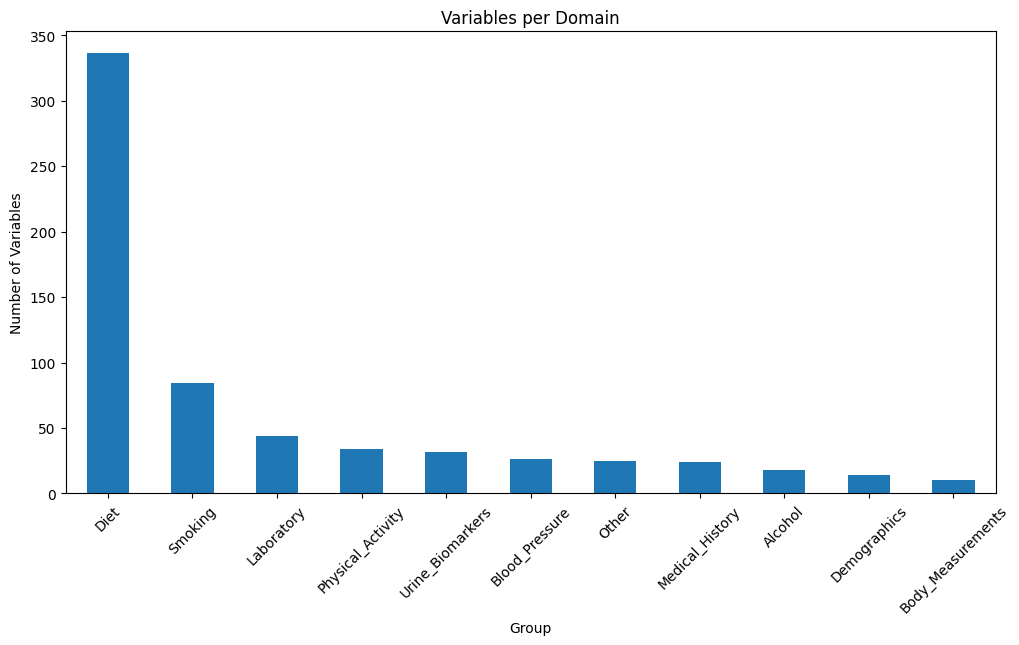

In [6]:
# plotting variables

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

dictionary["Group"].value_counts().plot(kind="bar")
5
plt.xticks(rotation=45)

plt.ylabel("Number of Variables")

plt.title("Variables per Domain")

plt.show()

In [7]:
# Data Dictionary

dictionary["DataType"] = [
    df[c].dtype
    for c in dictionary["Variable"]
]

dictionary["UniqueValues"] = [
    df[c].nunique()
    for c in dictionary["Variable"]
]

dictionary["Missing"] = [
    df[c].isna().sum()
    for c in dictionary["Variable"]
]

dictionary.head()

,Variable,Group,DataType,UniqueValues,Missing
0,SEQN,Other,int64,15560,0
1,SDMVPSU,Other,int64,3,0
2,SDMVSTRA,Other,int64,24,0
3,WTINTPRP,Other,float64,13537,0
4,WTMECPRP,Other,float64,12738,0


In [8]:
# Variables to Remove

remove_columns = [

    "SEQN",

    "SDMVPSU",

    "SDMVSTRA",

    "WTINTPRP",

    "WTMECPRP",

    "MCQ160B",

    "MCQ160C",

    "MCQ160D",

    "MCQ160E",

    "MCQ160F"

]

In [9]:
# Summary

print("Total Variables:", len(df.columns))
print("Variables for Removal:", len(remove_columns))
print("Variables Remaining:", len(df.columns) - len(remove_columns))

Total Variables: 647
Variables for Removal: 10
Variables Remaining: 637
